In [65]:
import numpy as np
from h5py import File as h5file
from sklearn.decomposition import NMF
from tifffile import imread


from nDTomo.methods.segmentation import get_model, FeatureConfig, get_features, load_labels, get_training_data, fit_model, apply

from os.path import join
import matplotlib.pyplot as plt

In [ ]:
file_path = '/media/ronan/T7/phd/data/XRDCT/nmc532_charged_1_00001_rec.h5'
with h5file(file_path, 'r') as f:
    # shape (h, w, c)
    hyperspectral_data = f['/data'][:]
    # TODO: crop from 50-400 channels
    hyperspectral_data = hyperspectral_data[:, :, :400]

In [ ]:
def fit_nmf(hs_data: np.ndarray, n_components: int, decimation_rate: int = 1) -> NMF:
    hs_decimated = hs_data[::decimation_rate, ::decimation_rate, :]
    h, w, c = hs_decimated.shape
    nmf = NMF(n_components=n_components, init='random', random_state=0)
    nmf.fit(hs_decimated.reshape(-1, c))
    return nmf

def apply_nmf(hs_data: np.ndarray, nmf_model: NMF) -> np.ndarray:
    h, w, c = hs_data.shape
    transformed = nmf_model.transform(hs_data.reshape(-1, c))
    return transformed.reshape(h, w, -1)

In [ ]:
seg_dir_path = p = '../../../nDTomo/examples/segmentation/'

img_path = join(seg_dir_path, 'NMC532_charged_sum_image.tif')
# mean_img = imread(img_path)
mean_img = np.sum(hyperspectral_data, axis=-1)

labels_path = join(seg_dir_path, 'NMC_532_charged_labels_v2.tif')
labels = load_labels(labels_path)

In [ ]:
plt.imsave('NMC532_charged_mean_image.png', mean_img, cmap='gray')

In [ ]:
cfg = FeatureConfig()
classical_features = get_features(mean_img, cfg)

In [ ]:
model = get_model(max_depth=8, class_weight="balanced")
train, targ = get_training_data(classical_features, labels)
model = fit_model(model, train, targ - 1)
segmentation = apply(model, classical_features)

/home/ronan/micromamba/envs/ndtomo/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [12:07:21] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
nmf = fit_nmf(hyperspectral_data, n_components=10, decimation_rate=2)
reduced_data = apply_nmf(hyperspectral_data, nmf)

/home/ronan/micromamba/envs/ndtomo/lib/python3.11/site-packages/sklearn/decomposition/_nmf.py:1728: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


In [ ]:
plus_xrd_features = get_features(mean_img, cfg, reduced_data)
plus_xrd_model = get_model(max_depth=8, class_weight="balanced")
plus_xrd_train, plus_xrd_targ = get_training_data(plus_xrd_features, labels)
plus_xrd_model = fit_model(plus_xrd_model, plus_xrd_train, plus_xrd_targ)
plus_xrd_segmentation = apply(plus_xrd_model, plus_xrd_features)

/home/ronan/micromamba/envs/ndtomo/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [12:07:59] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
print(classical_features.shape)

(629, 629, 58)


In [ ]:
from skimage.color import label2rgb
from PIL import Image, ImageColor

COLOURS: list[str] = [
    "#fafafa",
    "#003e83",
    # "#b5d1cc",
    "#fa2b00",
    "#ffb852",
    "#718600",
    "#8c564b",
    "#e377c2",
    "#7f7f7f",
    "#bcbd22",
    "#17becf",
]

color_list = [ImageColor.getcolor(c, "RGB") for c in COLOURS]
colors_normed = np.array(color_list) / 255.0


def apply_labels_as_overlay(labels: np.ndarray, img: Image.Image, colors: list, alpha: float = 1.0) -> Image.Image:
    labels_unsqueezed = np.expand_dims(labels, -1)

    overlay = label2rgb(labels, colors=colors, kind="overlay", bg_label=0, image_alpha=1, alpha=alpha)
    out = np.where(labels_unsqueezed, overlay * 255, np.array(img)).astype(np.uint8)
    img_with_labels = Image.fromarray(out)
    return img_with_labels

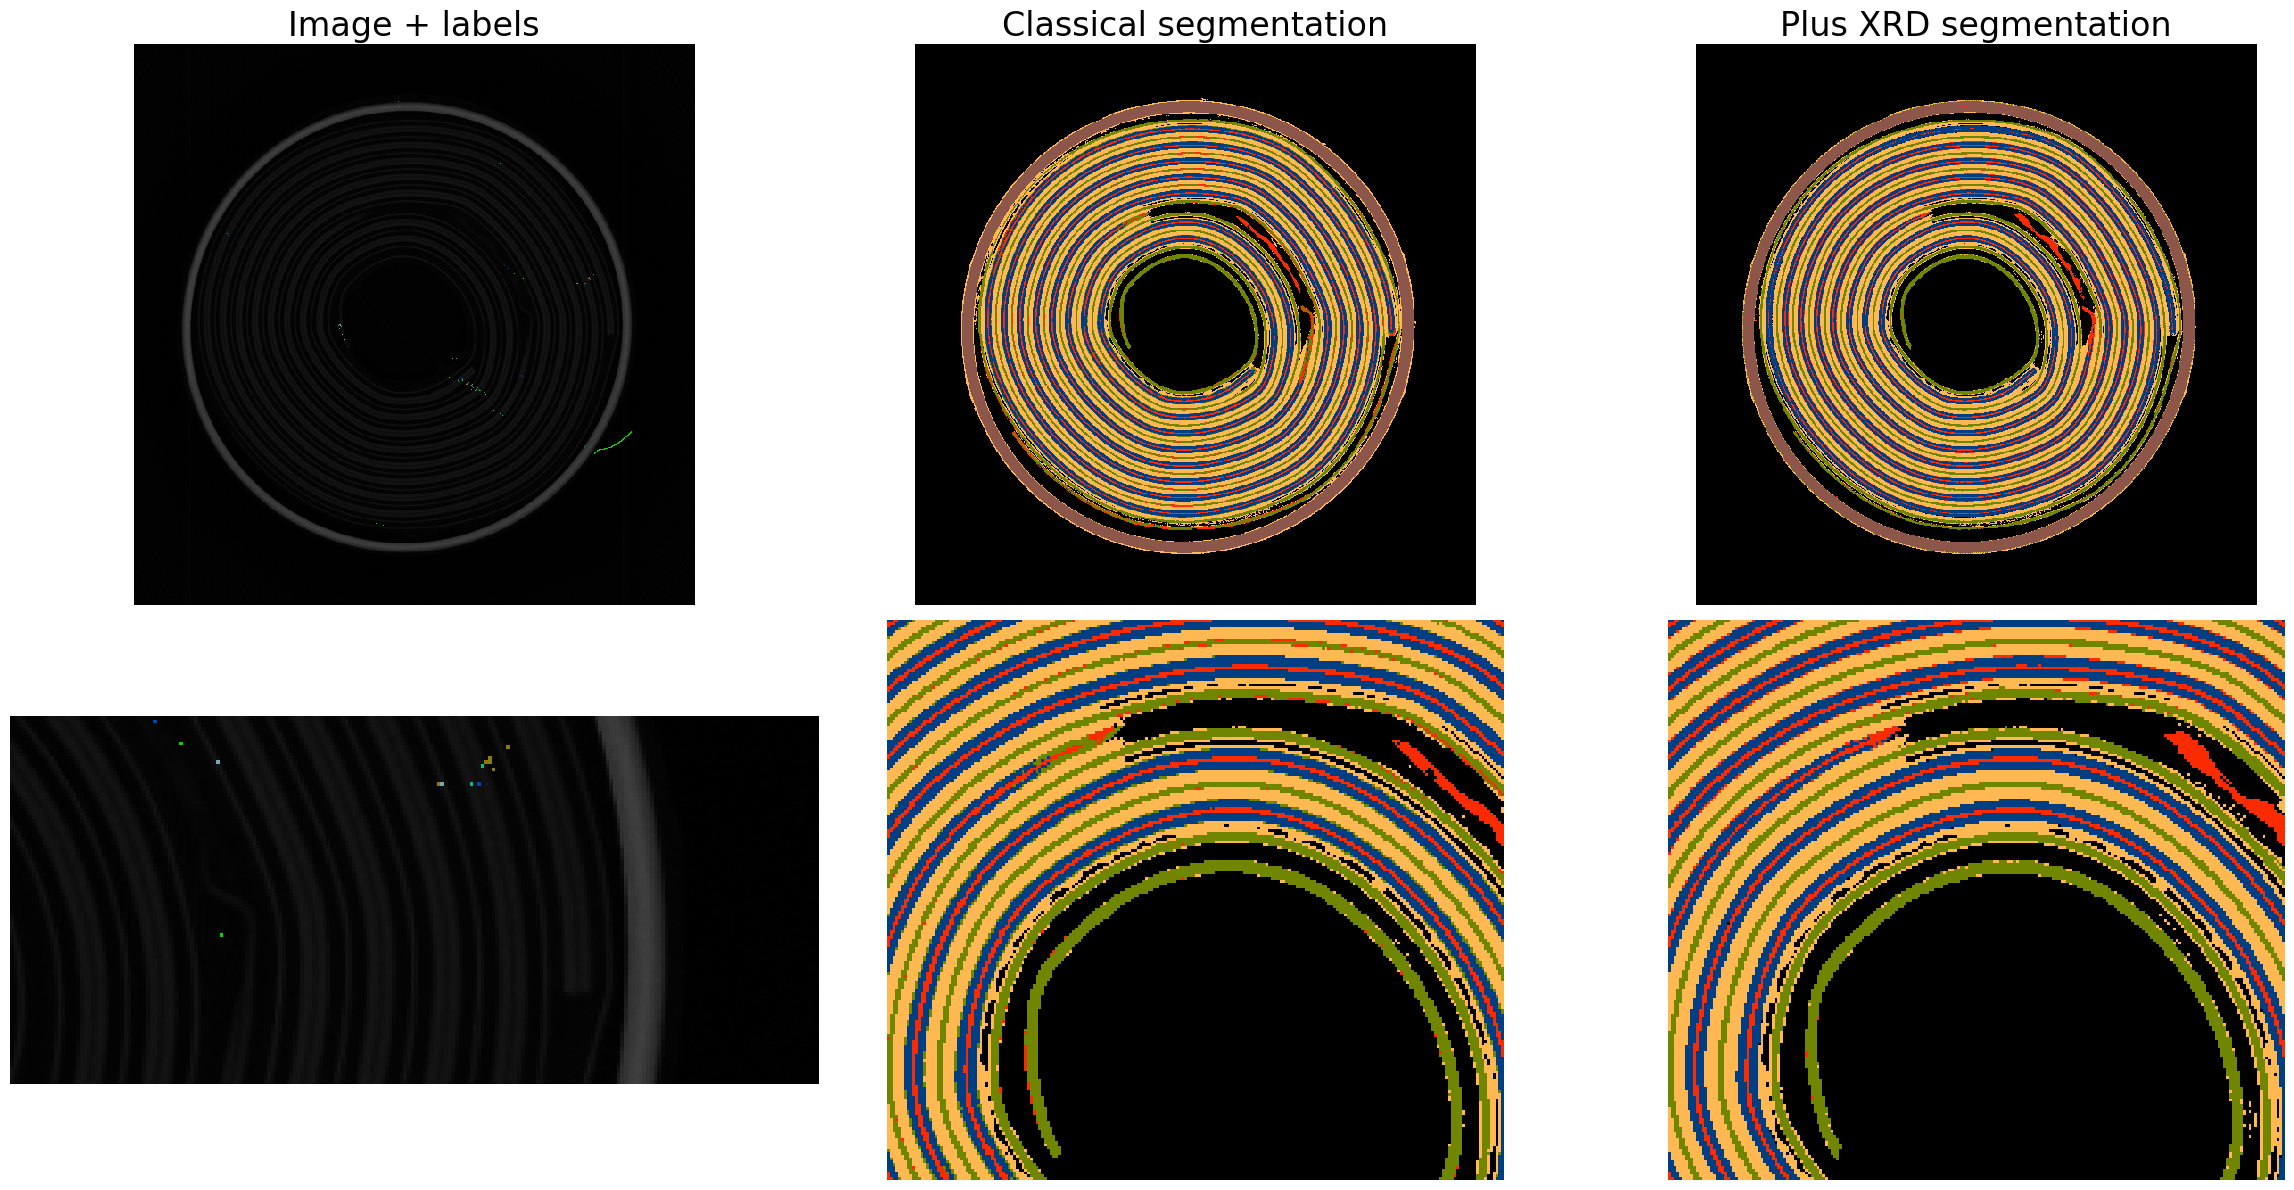

In [ ]:
fig, axs = plt.subplots(2, 3, figsize=(24, 12))


mean_img_rgb = Image.fromarray(mean_img).convert('RGB')
img_with_labels = apply_labels_as_overlay(labels, mean_img_rgb, color_list[1:], alpha=1)


BG_CLASS = 2
segmentation_with_bg = np.where(segmentation == BG_CLASS, 0, segmentation)
plus_xrd_segmentation_with_bg = np.where(plus_xrd_segmentation == BG_CLASS, 0, plus_xrd_segmentation)
classical_seg_remapped = label2rgb(segmentation_with_bg, colors=color_list[1:], kind="overlay", bg_label=0, image_alpha=1, alpha=1)
plus_xrd_seg_remapped = label2rgb(plus_xrd_segmentation_with_bg, colors=color_list[1:], kind="overlay", bg_label=0, image_alpha=1, alpha=1)

axs[0, 0].set_title('Image + labels', fontsize=24)
axs[0, 0].imshow(img_with_labels, interpolation='none')

axs[0, 1].set_title('Classical segmentation', fontsize=24)
axs[0, 1].imshow(classical_seg_remapped.astype(np.uint8), interpolation='none')

axs[0, 2].set_title('Plus XRD segmentation', fontsize=24)
axs[0, 2].imshow(plus_xrd_seg_remapped.astype(np.uint8), interpolation='none')

for ax in axs[0, :]:
    ax.axis('off')

zoom = np.s_[250:350, 380:600]
# zoom = np.s_[150:350, 180:400]

axs[1, 0].imshow(img_with_labels.crop((380, 250, 600, 350)), interpolation='none')
axs[1, 1].imshow(classical_seg_remapped[zoom].astype(np.uint8), interpolation='none')
axs[1, 2].imshow(plus_xrd_seg_remapped[zoom].astype(np.uint8), interpolation='none')

for ax in axs[1, :]:
    ax.axis('off')


plt.tight_layout()

# axs[0].set_title('Classical segmentation')
# axs[0].imshow(segmentation[250:350, 380:600], interpolation='none')
# axs[1].set_title('Plus XRD segmentation')
# axs[1].imshow(plus_xrd_segmentation[250:350, 380:600], interpolation='none')

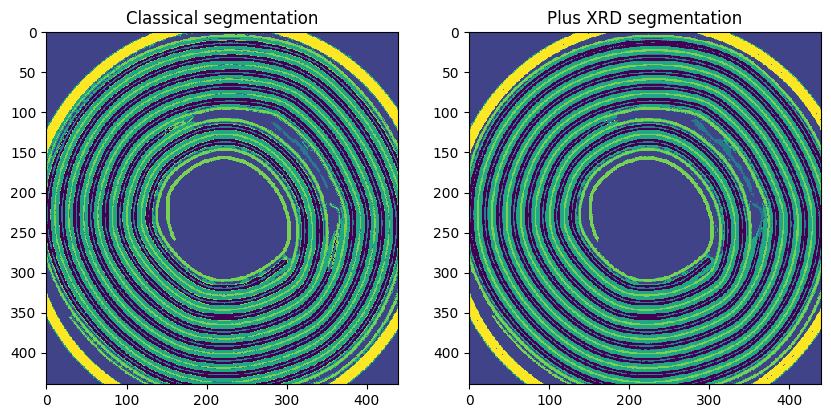

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].set_title('Classical segmentation')

s = np.s_[80:600-80, 80:600-80]
axs[0].imshow(segmentation[s], interpolation='none')
axs[1].set_title('Plus XRD segmentation')
axs[1].imshow(plus_xrd_segmentation[s], interpolation='none')